<a href="https://colab.research.google.com/github/mansur264/DS-Day01/blob/main/DS_Day01_50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# DS_Day01_50 — HR: WHICH TEAMS ARE OVERWORKED?
# STEP 1 — DATA LOADING, CLEANING & VALIDATION
# ============================================================

import pandas as pd
import numpy as np
from IPython.display import display

print("=" * 70)
print("DS_Day01_50 — HR TEAM WORKLOAD ANALYSIS")
print("STEP 1 — DATA LOADING & VALIDATION")
print("=" * 70)

# ============================================================
# 1. LOAD DATASET
# ============================================================

file_path = "/content/HR_Team_Workload_Analysis_36000.csv"

df = pd.read_csv(file_path)

print("\n✅ DATASET LOADED SUCCESSFULLY")
print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]:,}")


# ============================================================
# 2. BASIC PREVIEW
# ============================================================

print("\n" + "=" * 70)
print("1. FIRST 5 RECORDS")
print("=" * 70)

display(df.head())


# ============================================================
# 3. DATASET INFORMATION
# ============================================================

print("\n" + "=" * 70)
print("2. DATASET INFORMATION")
print("=" * 70)

df.info()


# ============================================================
# 4. COLUMN NAMES
# ============================================================

print("\n" + "=" * 70)
print("3. COLUMN NAMES")
print("=" * 70)

for i, col in enumerate(df.columns, 1):
    print(f"{i:2}. {col}")


# ============================================================
# 5. DATA TYPES
# ============================================================

print("\n" + "=" * 70)
print("4. DATA TYPES")
print("=" * 70)

display(
    pd.DataFrame({
        "Column": df.columns,
        "Data_Type": df.dtypes.astype(str).values,
        "Unique_Values": [df[col].nunique() for col in df.columns]
    })
)


# ============================================================
# 6. MISSING VALUES
# ============================================================

print("\n" + "=" * 70)
print("5. MISSING VALUES")
print("=" * 70)

missing_count = df.isnull().sum()
missing_percentage = (missing_count / len(df) * 100).round(2)

missing_table = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_percentage
})

display(missing_table)

if missing_count.sum() == 0:
    print("✅ No missing values found.")
else:
    print("⚠️ Missing values detected.")


# ============================================================
# 7. DUPLICATE RECORDS
# ============================================================

print("\n" + "=" * 70)
print("6. DUPLICATE RECORDS")
print("=" * 70)

duplicate_count = df.duplicated().sum()

print(f"Duplicate rows: {duplicate_count:,}")

if duplicate_count == 0:
    print("✅ No duplicate records found.")
else:
    print("⚠️ Duplicate records detected.")


# ============================================================
# 8. CONVERT MONTH TO DATETIME
# ============================================================

print("\n" + "=" * 70)
print("7. DATE VALIDATION")
print("=" * 70)

df["Month"] = pd.to_datetime(df["Month"], errors="coerce")

invalid_dates = df["Month"].isnull().sum()

print(f"Invalid dates: {invalid_dates}")

if invalid_dates == 0:
    print("✅ All Month values converted successfully.")
    print(f"Start Month : {df['Month'].min().strftime('%Y-%m')}")
    print(f"End Month   : {df['Month'].max().strftime('%Y-%m')}")
else:
    print("⚠️ Invalid date values detected.")


# ============================================================
# 9. UNIQUE TEAMS / DEPARTMENTS / MONTHS
# ============================================================

print("\n" + "=" * 70)
print("8. DATASET COVERAGE")
print("=" * 70)

unique_teams = df["Team_ID"].nunique()
unique_departments = df["Department"].nunique()
unique_months = df["Month"].nunique()

print(f"Unique Teams       : {unique_teams:,}")
print(f"Unique Departments : {unique_departments:,}")
print(f"Unique Months      : {unique_months:,}")


# ============================================================
# 10. TEAM-MONTH RECORD CONSISTENCY
# ============================================================

print("\n" + "=" * 70)
print("9. TEAM-MONTH CONSISTENCY")
print("=" * 70)

expected_records = unique_teams * unique_months
actual_records = len(df)

print(f"Expected Records : {expected_records:,}")
print(f"Actual Records   : {actual_records:,}")

if expected_records == actual_records:
    print("✅ Every team has the expected number of monthly records.")
else:
    print("⚠️ Team-month records require investigation.")


# ============================================================
# 11. DESCRIPTIVE STATISTICS
# ============================================================

print("\n" + "=" * 70)
print("10. DESCRIPTIVE STATISTICS")
print("=" * 70)

display(
    df.describe().T.round(2)
)


# ============================================================
# 12. DEPARTMENT DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("11. DEPARTMENT DISTRIBUTION")
print("=" * 70)

department_distribution = (
    df["Department"]
    .value_counts()
    .rename_axis("Department")
    .reset_index(name="Records")
)

display(department_distribution)


# ============================================================
# 13. WORKLOAD CATEGORY DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("12. WORKLOAD CATEGORY DISTRIBUTION")
print("=" * 70)

workload_distribution = (
    df["Workload_Category"]
    .value_counts()
    .rename_axis("Workload_Category")
    .reset_index(name="Records")
)

display(workload_distribution)


# ============================================================
# 14. OVERLOAD RISK DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("13. OVERLOAD RISK DISTRIBUTION")
print("=" * 70)

risk_distribution = (
    df["Overload_Risk"]
    .value_counts()
    .rename_axis("Overload_Risk")
    .reset_index(name="Records")
)

display(risk_distribution)

risk_percentage = (
    df["Overload_Risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nRisk Percentage:")
display(risk_percentage.rename("Percentage"))


# ============================================================
# 15. LOGICAL VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("14. LOGICAL VALIDATION")
print("=" * 70)

validation_checks = {
    "Project_Hours <= 0":
        (df["Project_Hours"] <= 0).sum(),

    "Employee_Count <= 0":
        (df["Employee_Count"] <= 0).sum(),

    "Overtime < 0":
        (df["Overtime"] < 0).sum(),

    "Leave < 0":
        (df["Leave"] < 0).sum(),

    "Deadlines < 0":
        (df["Deadlines"] < 0).sum(),

    "Project_Delivery < 0":
        (df["Project_Delivery"] < 0).sum(),

    "Satisfaction outside 1-10":
        (
            (df["Satisfaction_Score"] < 1) |
            (df["Satisfaction_Score"] > 10)
        ).sum(),

    "Workload_Per_Employee < 0":
        (df["Workload_Per_Employee"] < 0).sum(),

    "Overtime_Per_Employee < 0":
        (df["Overtime_Per_Employee"] < 0).sum(),

    "Delivery_Delay < 0":
        (df["Delivery_Delay"] < 0).sum()
}

validation_table = pd.DataFrame(
    list(validation_checks.items()),
    columns=["Validation_Check", "Invalid_Count"]
)

display(validation_table)

if validation_table["Invalid_Count"].sum() == 0:
    print("✅ All logical validation checks passed.")
else:
    print("⚠️ Some logical validation checks failed.")


# ============================================================
# 16. FEATURE CALCULATION VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("15. FEATURE CALCULATION VALIDATION")
print("=" * 70)

# Recalculate workload per employee
calculated_workload = (
    df["Project_Hours"] / df["Employee_Count"]
)

workload_difference = (
    calculated_workload -
    df["Workload_Per_Employee"]
).abs().max()

# Recalculate overtime per employee
calculated_overtime = (
    df["Overtime"] / df["Employee_Count"]
)

overtime_difference = (
    calculated_overtime -
    df["Overtime_Per_Employee"]
).abs().max()

print(
    f"Maximum Workload Calculation Difference : "
    f"{workload_difference:.10f}"
)

print(
    f"Maximum Overtime Calculation Difference : "
    f"{overtime_difference:.10f}"
)

if workload_difference < 0.000001:
    print("✅ Workload_Per_Employee is correctly calculated.")

if overtime_difference < 0.000001:
    print("✅ Overtime_Per_Employee is correctly calculated.")


# ============================================================
# 17. OUTLIER CHECK
# ============================================================

print("\n" + "=" * 70)
print("16. OUTLIER CHECK — IQR METHOD")
print("=" * 70)

numeric_columns = [
    "Project_Hours",
    "Employee_Count",
    "Overtime",
    "Leave",
    "Deadlines",
    "Project_Delivery",
    "Satisfaction_Score",
    "Workload_Per_Employee",
    "Overtime_Per_Employee",
    "Delivery_Delay"
]

outlier_results = []

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = (
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ).sum()

    outlier_results.append([
        col,
        round(Q1, 2),
        round(Q3, 2),
        round(lower_bound, 2),
        round(upper_bound, 2),
        int(outliers),
        round(outliers / len(df) * 100, 2)
    ])

outlier_table = pd.DataFrame(
    outlier_results,
    columns=[
        "Feature",
        "Q1",
        "Q3",
        "Lower_Bound",
        "Upper_Bound",
        "Outlier_Count",
        "Outlier_Percentage"
    ]
)

display(outlier_table)


# ============================================================
# 18. FINAL VALIDATION SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("17. FINAL DATA VALIDATION SUMMARY")
print("=" * 70)

total_missing = int(df.isnull().sum().sum())
total_duplicates = int(df.duplicated().sum())
total_invalid = int(validation_table["Invalid_Count"].sum())

print(f"Total Records          : {len(df):,}")
print(f"Total Columns          : {len(df.columns)}")
print(f"Unique Teams           : {unique_teams:,}")
print(f"Unique Departments     : {unique_departments}")
print(f"Unique Months          : {unique_months}")
print(f"Missing Values         : {total_missing:,}")
print(f"Duplicate Rows         : {total_duplicates:,}")
print(f"Invalid Values         : {total_invalid:,}")

if (
    len(df) == 36000
    and total_missing == 0
    and total_duplicates == 0
    and total_invalid == 0
    and invalid_dates == 0
):
    print("\n🎯 DATASET PASSED INITIAL VALIDATION")
    print("✅ Ready for Exploratory Data Analysis (EDA)")
else:
    print("\n⚠️ DATASET REQUIRES FURTHER VALIDATION")


# ============================================================
# 19. SAVE VALIDATED DATASET
# ============================================================

validated_path = "/content/HR_Team_Workload_Analysis_Validated.csv"

df.to_csv(validated_path, index=False)

print(f"\n✅ Validated dataset saved to:")
print(validated_path)

print("\n" + "=" * 70)
print("STEP 1 COMPLETE")
print("=" * 70)

DS_Day01_50 — HR TEAM WORKLOAD ANALYSIS
STEP 1 — DATA LOADING & VALIDATION

✅ DATASET LOADED SUCCESSFULLY
Rows    : 36,000
Columns : 17

1. FIRST 5 RECORDS


,Team_ID,Month,Department,Project_Hours,Employee_Count,Overtime,Leave,Deadlines,Project_Delivery,Satisfaction_Score,Workload_Per_Employee,Overtime_Per_Employee,Delivery_Delay,Workload_Category,Monthly_Overload,Consecutive_Overload_Months,Overload_Risk
0,T0001,2023-01-01,Software Development,833.731229,26,14.031241,8.534145,5,2,8.419374,32.066586,0.539663,0.00000,Low,0,0,Low
1,T0001,2023-02-01,Software Development,838.136737,26,1.365595,12.557302,7,9,8.539941,32.236028,0.052523,0.00000,Low,0,0,Low
2,T0001,2023-03-01,Software Development,845.103529,26,0.000000,16.229719,4,6,8.504802,32.503982,0.000000,4.46908,Low,0,0,Low
3,T0001,2023-04-01,Software Development,886.708983,26,0.000000,12.357372,5,6,9.604882,34.104192,0.000000,0.00000,Low,0,0,Low
4,T0001,2023-05-01,Software Development,926.528591,26,18.542786,11.470188,5,6,9.323008,35.635715,0.713184,0.00000,Normal,0,0,Low



2. DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36000 entries, 0 to 35999
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Team_ID                      36000 non-null  object 
 1   Month                        36000 non-null  object 
 2   Department                   36000 non-null  object 
 3   Project_Hours                36000 non-null  float64
 4   Employee_Count               36000 non-null  int64  
 5   Overtime                     36000 non-null  float64
 6   Leave                        36000 non-null  float64
 7   Deadlines                    36000 non-null  int64  
 8   Project_Delivery             36000 non-null  int64  
 9   Satisfaction_Score           36000 non-null  float64
 10  Workload_Per_Employee        36000 non-null  float64
 11  Overtime_Per_Employee        36000 non-null  float64
 12  Delivery_Delay               36000 non-null  float

,Column,Data_Type,Unique_Values
0,Team_ID,object,1000
1,Month,object,36
2,Department,object,10
3,Project_Hours,float64,35996
4,Employee_Count,int64,26
5,Overtime,float64,31591
6,Leave,float64,36000
7,Deadlines,int64,16
8,Project_Delivery,int64,17
9,Satisfaction_Score,float64,30742



5. MISSING VALUES


...


14. LOGICAL VALIDATION


,Validation_Check,Invalid_Count
0,Project_Hours <= 0,0
1,Employee_Count <= 0,0
2,Overtime < 0,0
3,Leave < 0,0
4,Deadlines < 0,0
5,Project_Delivery < 0,0
6,Satisfaction outside 1-10,0
7,Workload_Per_Employee < 0,0
8,Overtime_Per_Employee < 0,0
9,Delivery_Delay < 0,0


✅ All logical validation checks passed.

15. FEATURE CALCULATION VALIDATION
Maximum Workload Calculation Difference : 0.0000000000
Maximum Overtime Calculation Difference : 0.0000000000
✅ Workload_Per_Employee is correctly calculated.
✅ Overtime_Per_Employee is correctly calculated.

16. OUTLIER CHECK — IQR METHOD


,Feature,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,Project_Hours,784.14,1118.05,283.28,1618.91,528,1.47
1,Employee_Count,11.00,24.00,-8.50,43.50,0,0.00
2,Overtime,17.39,195.70,-250.06,463.15,216,0.60
3,Leave,12.82,27.50,-9.19,49.51,2468,6.86
4,Deadlines,4.00,7.00,-0.50,11.50,381,1.06
5,Project_Delivery,3.00,7.00,-3.00,13.00,57,0.16
6,Satisfaction_Score,3.88,8.45,-2.96,15.29,0,0.00
7,Workload_Per_Employee,39.67,88.22,-33.16,161.04,2178,6.05
8,Overtime_Per_Employee,0.75,16.92,-23.50,41.17,2363,6.56
9,Delivery_Delay,0.67,19.38,-27.38,47.43,2846,7.91



17. FINAL DATA VALIDATION SUMMARY
Total Records          : 36,000
Total Columns          : 17
Unique Teams           : 1,000
Unique Departments     : 10
Unique Months          : 36
Missing Values         : 0
Duplicate Rows         : 0
Invalid Values         : 0

🎯 DATASET PASSED INITIAL VALIDATION
✅ Ready for Exploratory Data Analysis (EDA)

✅ Validated dataset saved to:
/content/HR_Team_Workload_Analysis_Validated.csv

STEP 1 COMPLETE


In [ ]:
# ============================================================
# STEP 2 — EXPLORATORY DATA ANALYSIS
# ============================================================

import pandas as pd
import numpy as np
from IPython.display import display

print("=" * 70)
print("STEP 2 — EXPLORATORY DATA ANALYSIS")
print("=" * 70)

# Load validated dataset
df = pd.read_csv("/content/HR_Team_Workload_Analysis_Validated.csv")

df["Month"] = pd.to_datetime(df["Month"])

# ============================================================
# 1. OVERALL DESCRIPTIVE STATISTICS
# ============================================================

print("\n" + "=" * 70)
print("1. OVERALL DESCRIPTIVE STATISTICS")
print("=" * 70)

numeric_cols = [
    "Project_Hours",
    "Employee_Count",
    "Overtime",
    "Leave",
    "Deadlines",
    "Project_Delivery",
    "Satisfaction_Score",
    "Workload_Per_Employee",
    "Overtime_Per_Employee",
    "Delivery_Delay"
]

display(
    df[numeric_cols]
    .describe()
    .T
    .round(2)
)


# ============================================================
# 2. WORKLOAD ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("2. WORKLOAD PER EMPLOYEE ANALYSIS")
print("=" * 70)

workload_summary = (
    df.groupby("Team_ID")
    .agg(
        Avg_Workload=("Workload_Per_Employee", "mean"),
        Max_Workload=("Workload_Per_Employee", "max"),
        Avg_Employees=("Employee_Count", "mean"),
        Avg_Project_Hours=("Project_Hours", "mean")
    )
    .sort_values("Avg_Workload", ascending=False)
)

print("\nTop 10 teams by average workload:")
display(workload_summary.head(10).round(2))


# ============================================================
# 3. SUSTAINED OVERTIME
# ============================================================

print("\n" + "=" * 70)
print("3. SUSTAINED OVERTIME ANALYSIS")
print("=" * 70)

overtime_summary = (
    df.groupby("Team_ID")
    .agg(
        Avg_Overtime_Per_Employee=("Overtime_Per_Employee", "mean"),
        Max_Overtime_Per_Employee=("Overtime_Per_Employee", "max"),
        Months_With_Overtime=(
            "Overtime_Per_Employee",
            lambda x: (x > 6).sum()
        ),
        Total_Overtime=("Overtime", "sum")
    )
    .sort_values(
        ["Months_With_Overtime", "Avg_Overtime_Per_Employee"],
        ascending=False
    )
)

print("\nTop 10 teams with sustained overtime:")
display(overtime_summary.head(10).round(2))


# ============================================================
# 4. OVERTIME VS PROJECT DELAYS
# ============================================================

print("\n" + "=" * 70)
print("4. OVERTIME VS PROJECT DELAYS")
print("=" * 70)

overtime_delay_corr = df[
    ["Overtime_Per_Employee", "Delivery_Delay"]
].corr().iloc[0, 1]

print(
    f"Correlation between overtime per employee "
    f"and delivery delay: {overtime_delay_corr:.3f}"
)

if overtime_delay_corr > 0:
    print("📌 Higher overtime is positively associated with project delays.")
elif overtime_delay_corr < 0:
    print("📌 Higher overtime is negatively associated with project delays.")
else:
    print("📌 No linear relationship detected.")


# ============================================================
# 5. WORKLOAD VS SATISFACTION
# ============================================================

print("\n" + "=" * 70)
print("5. WORKLOAD VS EMPLOYEE SATISFACTION")
print("=" * 70)

workload_satisfaction_corr = df[
    ["Workload_Per_Employee", "Satisfaction_Score"]
].corr().iloc[0, 1]

print(
    f"Correlation between workload per employee "
    f"and satisfaction: {workload_satisfaction_corr:.3f}"
)

if workload_satisfaction_corr < 0:
    print("📌 Higher workload is associated with lower satisfaction.")
elif workload_satisfaction_corr > 0:
    print("📌 Higher workload is associated with higher satisfaction.")
else:
    print("📌 No linear relationship detected.")


# ============================================================
# 6. WORKLOAD CATEGORY ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("6. WORKLOAD CATEGORY ANALYSIS")
print("=" * 70)

category_analysis = (
    df.groupby("Workload_Category", observed=True)
    .agg(
        Records=("Team_ID", "count"),
        Avg_Workload=("Workload_Per_Employee", "mean"),
        Avg_Overtime=("Overtime_Per_Employee", "mean"),
        Avg_Delay=("Delivery_Delay", "mean"),
        Avg_Satisfaction=("Satisfaction_Score", "mean")
    )
    .sort_values("Avg_Workload")
)

display(category_analysis.round(2))


# ============================================================
# 7. TEMPORARY SPIKES VS CHRONIC OVERLOAD
# ============================================================

print("\n" + "=" * 70)
print("7. TEMPORARY SPIKES VS CHRONIC OVERLOAD")
print("=" * 70)

team_overload = (
    df.groupby("Team_ID")
    .agg(
        Total_Overloaded_Months=("Monthly_Overload", "sum"),
        Max_Consecutive_Overload=(
            "Consecutive_Overload_Months",
            "max"
        ),
        Avg_Workload=("Workload_Per_Employee", "mean"),
        Avg_Overtime=("Overtime_Per_Employee", "mean")
    )
)

# Temporary spike:
# overloaded for 1–2 months but no long consecutive period
temporary_spikes = team_overload[
    (team_overload["Total_Overloaded_Months"] > 0) &
    (team_overload["Total_Overloaded_Months"] <= 2) &
    (team_overload["Max_Consecutive_Overload"] <= 2)
]

# Chronic overload:
# 3 or more consecutive overloaded months
chronic_overload = team_overload[
    team_overload["Max_Consecutive_Overload"] >= 3
]

print(f"Teams with temporary workload spikes : {len(temporary_spikes)}")
print(f"Teams with chronic overload           : {len(chronic_overload)}")

print("\nTop 10 chronically overloaded teams:")
display(
    chronic_overload
    .sort_values(
        ["Max_Consecutive_Overload", "Avg_Workload"],
        ascending=False
    )
    .head(10)
    .round(2)
)


# ============================================================
# 8. DEPARTMENT ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("8. DEPARTMENT-LEVEL ANALYSIS")
print("=" * 70)

department_analysis = (
    df.groupby("Department")
    .agg(
        Avg_Workload=("Workload_Per_Employee", "mean"),
        Avg_Overtime=("Overtime_Per_Employee", "mean"),
        Avg_Delay=("Delivery_Delay", "mean"),
        Avg_Satisfaction=("Satisfaction_Score", "mean"),
        High_Risk_Records=(
            "Overload_Risk",
            lambda x: (x == "High").sum()
        )
    )
    .sort_values("Avg_Workload", ascending=False)
)

display(department_analysis.round(2))


# ============================================================
# 9. MONTHLY WORKLOAD TREND
# ============================================================

print("\n" + "=" * 70)
print("9. MONTHLY WORKLOAD TREND")
print("=" * 70)

monthly_trend = (
    df.groupby("Month")
    .agg(
        Avg_Workload=("Workload_Per_Employee", "mean"),
        Avg_Overtime=("Overtime_Per_Employee", "mean"),
        Avg_Delay=("Delivery_Delay", "mean"),
        Avg_Satisfaction=("Satisfaction_Score", "mean")
    )
    .reset_index()
)

display(monthly_trend.round(2))


# ============================================================
# 10. KEY EDA FINDINGS
# ============================================================

print("\n" + "=" * 70)
print("STEP 2 — EDA SUMMARY")
print("=" * 70)

print(f"""
Average workload per employee : {df['Workload_Per_Employee'].mean():.2f}
Average overtime per employee : {df['Overtime_Per_Employee'].mean():.2f}
Average delivery delay        : {df['Delivery_Delay'].mean():.2f}
Average satisfaction          : {df['Satisfaction_Score'].mean():.2f}

Overtime ↔ Delay correlation   : {overtime_delay_corr:.3f}
Workload ↔ Satisfaction corr.  : {workload_satisfaction_corr:.3f}

Temporary spike teams          : {len(temporary_spikes)}
Chronic overload teams         : {len(chronic_overload)}
""")

print("✅ STEP 2 — EDA COMPLETE")

STEP 2 — EXPLORATORY DATA ANALYSIS

1. OVERALL DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
Project_Hours,36000.0,962.93,257.87,300.0,784.14,942.78,1118.05,2180.51
Employee_Count,36000.0,17.41,7.57,5.0,11.00,17.00,24.00,30.00
Overtime,36000.0,121.43,111.07,0.0,17.39,100.10,195.70,672.69
Leave,36000.0,22.50,14.55,0.0,12.82,17.32,27.50,113.01
Deadlines,36000.0,5.57,2.29,1.0,4.00,5.00,7.00,16.00
Project_Delivery,36000.0,5.47,2.91,0.0,3.00,6.00,7.00,16.00
Satisfaction_Score,36000.0,6.07,2.86,1.0,3.88,7.21,8.45,10.00
Workload_Per_Employee,36000.0,71.01,45.74,10.0,39.67,56.01,88.22,343.60
Overtime_Per_Employee,36000.0,11.96,15.34,0.0,0.75,6.08,16.92,123.89
Delivery_Delay,36000.0,13.86,19.64,0.0,0.67,4.91,19.38,152.71



2. WORKLOAD PER EMPLOYEE ANALYSIS

Top 10 teams by average workload:


,Avg_Workload,Max_Workload,Avg_Employees,Avg_Project_Hours
Team_ID,,,,
T0783,279.94,338.75,5.0,1399.71
T0399,275.45,343.60,5.0,1377.23
T0450,252.30,311.50,7.0,1766.10
T0167,243.33,284.86,5.0,1216.63
T0070,240.55,267.76,5.0,1202.75
T0807,233.53,270.73,5.0,1167.66
T0801,233.38,274.48,6.0,1400.30
T0739,233.12,274.32,5.0,1165.62
T0763,232.79,275.82,5.0,1163.96



3. SUSTAINED OVERTIME ANALYSIS

Top 10 teams with sustained overtime:


...


8. DEPARTMENT-LEVEL ANALYSIS


,Avg_Workload,Avg_Overtime,Avg_Delay,Avg_Satisfaction,High_Risk_Records
Department,,,,,
Cybersecurity,76.09,13.84,16.11,5.68,2000
Cloud & DevOps,75.28,13.38,15.73,5.78,1519
Data & Analytics,75.07,12.97,15.07,5.91,1241
Project Management,75.01,13.25,15.45,5.76,1702
Infrastructure,73.81,12.74,14.52,5.97,1560
IT Support,71.66,12.36,14.39,6.09,1619
Software Development,68.02,10.60,12.35,6.31,1371
QA & Testing,66.77,10.67,12.35,6.38,1544
UI/UX,66.00,10.39,11.90,6.20,1410



9. MONTHLY WORKLOAD TREND


,Month,Avg_Workload,Avg_Overtime,Avg_Delay,Avg_Satisfaction
0,2023-01-01,70.64,11.87,13.71,6.08
1,2023-02-01,70.78,11.92,13.82,6.07
2,2023-03-01,71.17,12.06,13.93,6.07
3,2023-04-01,70.90,11.96,13.80,6.07
4,2023-05-01,71.18,12.00,13.93,6.06
5,2023-06-01,71.17,12.00,13.89,6.07
6,2023-07-01,71.01,11.96,13.91,6.05
7,2023-08-01,71.42,12.08,14.07,6.08
8,2023-09-01,70.94,11.91,13.86,6.06
9,2023-10-01,70.91,11.92,13.73,6.08



STEP 2 — EDA SUMMARY

Average workload per employee : 71.01
Average overtime per employee : 11.96
Average delivery delay        : 13.86
Average satisfaction          : 6.07

Overtime ↔ Delay correlation   : 0.990
Workload ↔ Satisfaction corr.  : -0.911

Temporary spike teams          : 52
Chronic overload teams         : 559

✅ STEP 2 — EDA COMPLETE


STEP 3 — VISUALIZATIONS


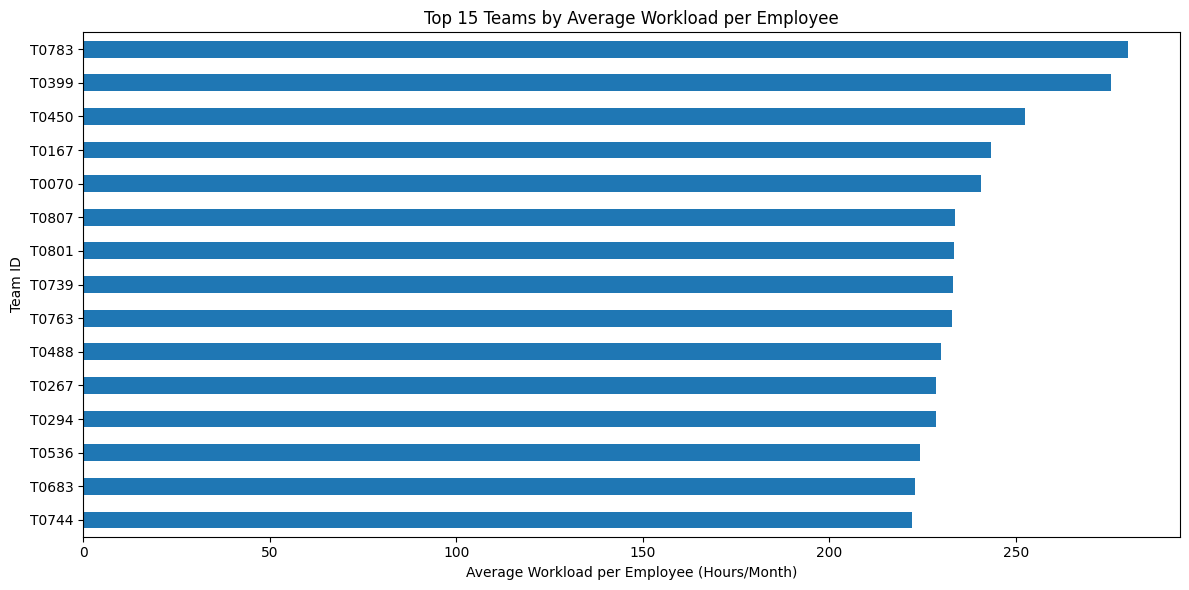

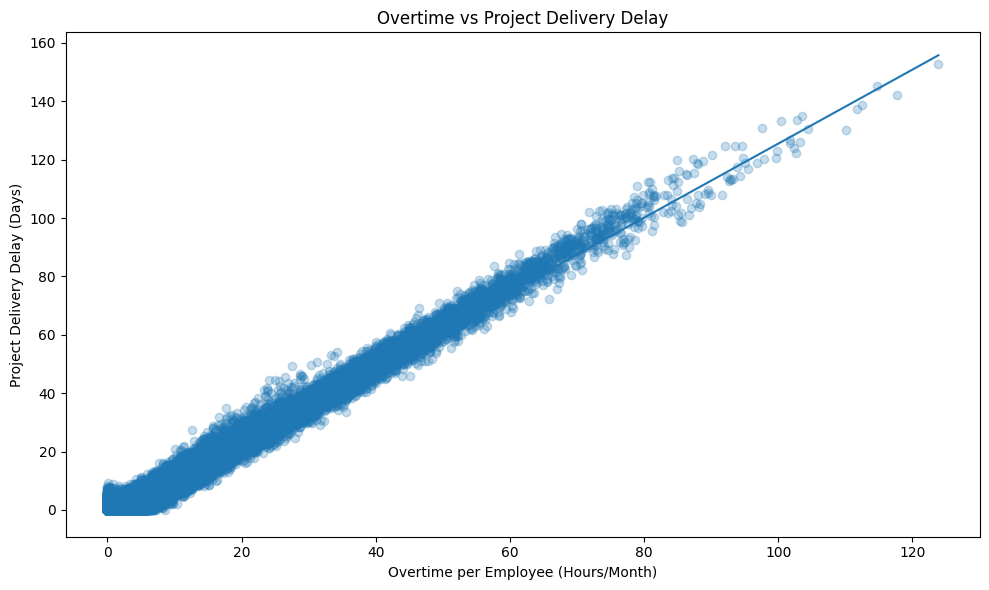

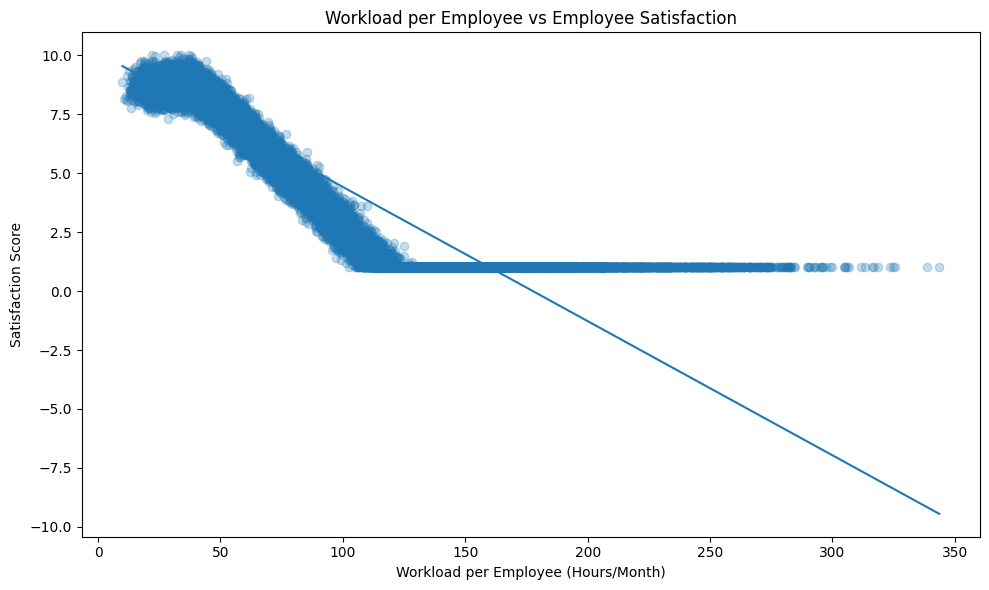

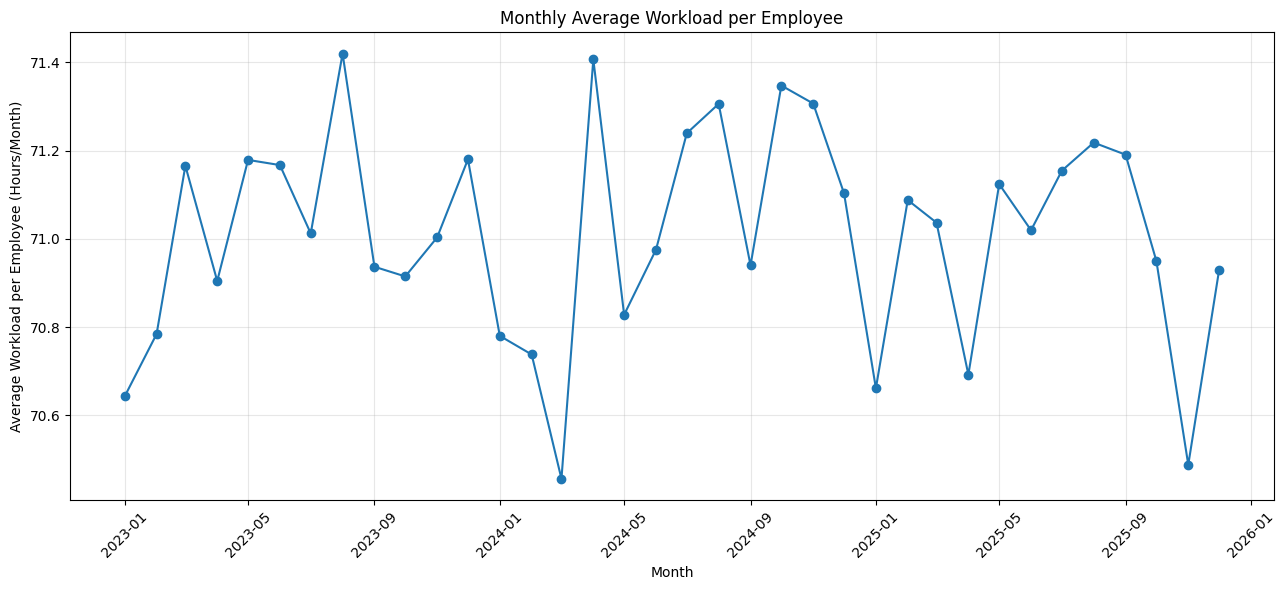


STEP 3 COMPLETE

✅ Visualization 1: Team workload
✅ Visualization 2: Overtime vs project delays
✅ Visualization 3: Workload vs satisfaction
✅ Visualization 4: Monthly workload trend



In [ ]:
# ============================================================
# STEP 3 — REQUIRED VISUALIZATIONS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# Load validated dataset
df = pd.read_csv("/content/HR_Team_Workload_Analysis_Validated.csv")
df["Month"] = pd.to_datetime(df["Month"])

print("=" * 70)
print("STEP 3 — VISUALIZATIONS")
print("=" * 70)


# ============================================================
# VISUALIZATION 1
# TOP 15 TEAMS BY AVERAGE WORKLOAD
# ============================================================

team_workload = (
    df.groupby("Team_ID")["Workload_Per_Employee"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12, 6))

team_workload.sort_values().plot(kind="barh")

plt.title("Top 15 Teams by Average Workload per Employee")
plt.xlabel("Average Workload per Employee (Hours/Month)")
plt.ylabel("Team ID")
plt.tight_layout()
plt.show()


# ============================================================
# VISUALIZATION 2
# OVERTIME VS PROJECT DELAYS
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Overtime_Per_Employee"],
    df["Delivery_Delay"],
    alpha=0.25
)

# Trend line
x = df["Overtime_Per_Employee"]
y = df["Delivery_Delay"]

z = __import__("numpy").polyfit(x, y, 1)
p = __import__("numpy").poly1d(z)

plt.plot(
    x.sort_values(),
    p(x.sort_values())
)

plt.title("Overtime vs Project Delivery Delay")
plt.xlabel("Overtime per Employee (Hours/Month)")
plt.ylabel("Project Delivery Delay (Days)")
plt.tight_layout()
plt.show()


# ============================================================
# VISUALIZATION 3
# WORKLOAD VS EMPLOYEE SATISFACTION
# ============================================================

plt.figure(figsize=(10, 6))

plt.scatter(
    df["Workload_Per_Employee"],
    df["Satisfaction_Score"],
    alpha=0.25
)

x = df["Workload_Per_Employee"]
y = df["Satisfaction_Score"]

z = __import__("numpy").polyfit(x, y, 1)
p = __import__("numpy").poly1d(z)

plt.plot(
    x.sort_values(),
    p(x.sort_values())
)

plt.title("Workload per Employee vs Employee Satisfaction")
plt.xlabel("Workload per Employee (Hours/Month)")
plt.ylabel("Satisfaction Score")
plt.tight_layout()
plt.show()


# ============================================================
# VISUALIZATION 4
# MONTHLY WORKLOAD TREND
# ============================================================

monthly_workload = (
    df.groupby("Month")["Workload_Per_Employee"]
    .mean()
)

plt.figure(figsize=(13, 6))

plt.plot(
    monthly_workload.index,
    monthly_workload.values,
    marker="o"
)

plt.title("Monthly Average Workload per Employee")
plt.xlabel("Month")
plt.ylabel("Average Workload per Employee (Hours/Month)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


print("\n" + "=" * 70)
print("STEP 3 COMPLETE")
print("=" * 70)

print("""
✅ Visualization 1: Team workload
✅ Visualization 2: Overtime vs project delays
✅ Visualization 3: Workload vs satisfaction
✅ Visualization 4: Monthly workload trend
""")

STEP 4 — RANDOM FOREST MODEL

1. TARGET DISTRIBUTION
Overload_Risk
High      15379
Low       14815
Medium     5806
Name: count, dtype: int64

Target percentage:
Overload_Risk
High      42.72
Low       41.15
Medium    16.13
Name: proportion, dtype: float64

2. TRAIN / TEST SPLIT
Training records : 28,800
Testing records  : 7,200

3. TRAINING RANDOM FOREST
✅ Random Forest training completed.

4. MODEL EVALUATION
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000

5. CLASSIFICATION REPORT
              precision    recall  f1-score   support

        High       1.00      1.00      1.00      3076
         Low       1.00      1.00      1.00      2963
      Medium       1.00      1.00      1.00      1161

    accuracy                           1.00      7200
   macro avg       1.00      1.00      1.00      7200
weighted avg       1.00      1.00      1.00      7200


6. CONFUSION MATRIX
[[3076    0    0]
 [   0 2963    0]
 [   0    0 1161]]


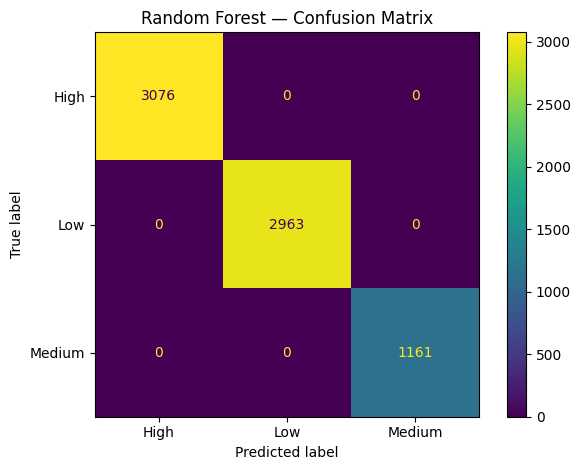


7. FEATURE IMPORTANCE


,Feature,Importance
0,numeric__Consecutive_Overload_Months,0.318243
1,numeric__Workload_Per_Employee,0.218454
2,numeric__Overtime_Per_Employee,0.142314
3,numeric__Satisfaction_Score,0.091505
4,numeric__Delivery_Delay,0.085417
5,numeric__Overtime,0.066173
6,numeric__Leave,0.036423
7,numeric__Employee_Count,0.024970
8,numeric__Project_Hours,0.006714
9,numeric__Project_Delivery,0.004893


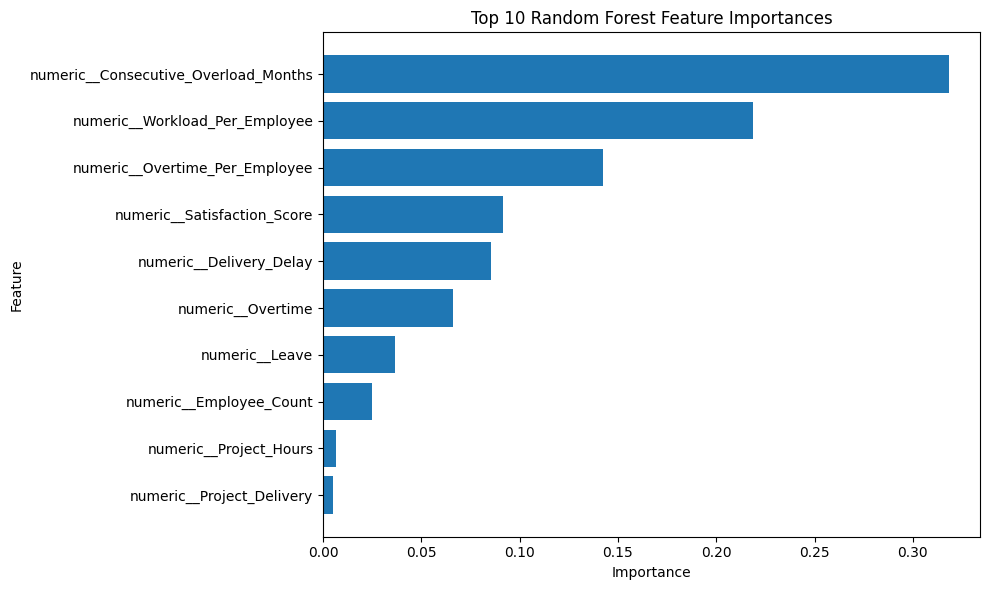


8. MODEL SAVED
✅ Model saved to:
/content/random_forest_overload_model.pkl

STEP 4 COMPLETE

✅ Random Forest trained
✅ Predictions generated
✅ Accuracy calculated
✅ Precision calculated
✅ Recall calculated
✅ F1-score calculated
✅ Classification report generated
✅ Confusion matrix generated
✅ Feature importance generated
✅ Model saved



In [ ]:
# ============================================================
# STEP 4 — RANDOM FOREST MODEL
# ============================================================

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score
)

import matplotlib.pyplot as plt

print("=" * 70)
print("STEP 4 — RANDOM FOREST MODEL")
print("=" * 70)


# ============================================================
# 1. LOAD DATA
# ============================================================

df = pd.read_csv(
    "/content/HR_Team_Workload_Analysis_Validated.csv"
)

df["Month"] = pd.to_datetime(df["Month"])


# ============================================================
# 2. SELECT FEATURES
# ============================================================

features = [
    "Department",
    "Project_Hours",
    "Employee_Count",
    "Overtime",
    "Leave",
    "Deadlines",
    "Project_Delivery",
    "Satisfaction_Score",
    "Workload_Per_Employee",
    "Overtime_Per_Employee",
    "Delivery_Delay",
    "Consecutive_Overload_Months"
]

target = "Overload_Risk"

X = df[features]
y = df[target]


# ============================================================
# 3. CHECK TARGET DISTRIBUTION
# ============================================================

print("\n" + "=" * 70)
print("1. TARGET DISTRIBUTION")
print("=" * 70)

print(y.value_counts())

print("\nTarget percentage:")
print(
    (y.value_counts(normalize=True) * 100)
    .round(2)
)


# ============================================================
# 4. TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 70)
print("2. TRAIN / TEST SPLIT")
print("=" * 70)

print(f"Training records : {len(X_train):,}")
print(f"Testing records  : {len(X_test):,}")


# ============================================================
# 5. PREPROCESSING
# ============================================================

categorical_features = [
    "Department"
]

numeric_features = [
    "Project_Hours",
    "Employee_Count",
    "Overtime",
    "Leave",
    "Deadlines",
    "Project_Delivery",
    "Satisfaction_Score",
    "Workload_Per_Employee",
    "Overtime_Per_Employee",
    "Delivery_Delay",
    "Consecutive_Overload_Months"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)


# ============================================================
# 6. RANDOM FOREST
# ============================================================

random_forest = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)


# ============================================================
# 7. CREATE PIPELINE
# ============================================================

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", random_forest)
    ]
)


# ============================================================
# 8. TRAIN MODEL
# ============================================================

print("\n" + "=" * 70)
print("3. TRAINING RANDOM FOREST")
print("=" * 70)

model.fit(X_train, y_train)

print("✅ Random Forest training completed.")


# ============================================================
# 9. PREDICTIONS
# ============================================================

y_pred = model.predict(X_test)
y_probability = model.predict_proba(X_test)


# ============================================================
# 10. MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)


print("\n" + "=" * 70)
print("4. MODEL EVALUATION")
print("=" * 70)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")


# ============================================================
# 11. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 70)
print("5. CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred,
        zero_division=0
    )
)


# ============================================================
# 12. CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 70)
print("6. CONFUSION MATRIX")
print("=" * 70)

cm = confusion_matrix(y_test, y_pred)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
).plot()

plt.title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.show()


# ============================================================
# 13. FEATURE IMPORTANCE
# ============================================================

print("\n" + "=" * 70)
print("7. FEATURE IMPORTANCE")
print("=" * 70)

rf_model = model.named_steps["classifier"]

feature_names = (
    model.named_steps["preprocessor"]
    .get_feature_names_out()
)

importance = rf_model.feature_importances_

feature_importance = (
    pd.DataFrame({
        "Feature": feature_names,
        "Importance": importance
    })
    .sort_values("Importance", ascending=False)
)

display(
    feature_importance
    .head(15)
    .reset_index(drop=True)
)


# ============================================================
# 14. FEATURE IMPORTANCE VISUALIZATION
# ============================================================

top_features = feature_importance.head(10).sort_values(
    "Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 10 Random Forest Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


# ============================================================
# 15. SAVE MODEL
# ============================================================

import joblib

model_path = "/content/random_forest_overload_model.pkl"

joblib.dump(model, model_path)

print("\n" + "=" * 70)
print("8. MODEL SAVED")
print("=" * 70)

print(f"✅ Model saved to:")
print(model_path)


# ============================================================
# FINAL
# ============================================================

print("\n" + "=" * 70)
print("STEP 4 COMPLETE")
print("=" * 70)

print("""
✅ Random Forest trained
✅ Predictions generated
✅ Accuracy calculated
✅ Precision calculated
✅ Recall calculated
✅ F1-score calculated
✅ Classification report generated
✅ Confusion matrix generated
✅ Feature importance generated
✅ Model saved
""")

In [ ]:
# ============================================================
# STEP 5 — FINAL HACKATHON INSIGHTS & ACTION PLAN
# ============================================================

import pandas as pd
import numpy as np

print("=" * 75)
print("DS_Day01_50 — FINAL RESULTS")
print("HR: WHICH TEAMS ARE OVERWORKED?")
print("=" * 75)


# ============================================================
# 1. LOAD VALIDATED DATASET
# ============================================================

df = pd.read_csv(
    "/content/HR_Team_Workload_Analysis_Validated.csv"
)

df["Month"] = pd.to_datetime(df["Month"])


# ============================================================
# 2. OVERALL METRICS
# ============================================================

avg_workload = df["Workload_Per_Employee"].mean()
avg_overtime = df["Overtime_Per_Employee"].mean()
avg_delay = df["Delivery_Delay"].mean()
avg_satisfaction = df["Satisfaction_Score"].mean()

overtime_delay_corr = df[
    ["Overtime_Per_Employee", "Delivery_Delay"]
].corr().iloc[0, 1]

workload_satisfaction_corr = df[
    ["Workload_Per_Employee", "Satisfaction_Score"]
].corr().iloc[0, 1]


# ============================================================
# 3. TEAM-LEVEL ANALYSIS
# ============================================================

team_summary = (
    df.groupby("Team_ID")
    .agg(
        Avg_Workload=("Workload_Per_Employee", "mean"),
        Avg_Overtime=("Overtime_Per_Employee", "mean"),
        Avg_Delay=("Delivery_Delay", "mean"),
        Avg_Satisfaction=("Satisfaction_Score", "mean"),
        Overloaded_Months=("Monthly_Overload", "sum"),
        Max_Consecutive_Overload=(
            "Consecutive_Overload_Months",
            "max"
        )
    )
)


# ============================================================
# 4. TOP WORKLOAD TEAM
# ============================================================

top_workload_team = team_summary[
    "Avg_Workload"
].idxmax()

top_workload_value = team_summary.loc[
    top_workload_team,
    "Avg_Workload"
]


# ============================================================
# 5. TOP OVERTIME TEAM
# ============================================================

top_overtime_team = team_summary[
    "Avg_Overtime"
].idxmax()

top_overtime_value = team_summary.loc[
    top_overtime_team,
    "Avg_Overtime"
]


# ============================================================
# 6. TOP DELAY TEAM
# ============================================================

top_delay_team = team_summary[
    "Avg_Delay"
].idxmax()

top_delay_value = team_summary.loc[
    top_delay_team,
    "Avg_Delay"
]


# ============================================================
# 7. CHRONIC VS TEMPORARY OVERLOAD
# ============================================================

chronic_teams = team_summary[
    team_summary["Max_Consecutive_Overload"] >= 3
]

temporary_teams = team_summary[
    (team_summary["Overloaded_Months"] > 0)
    & (team_summary["Overloaded_Months"] <= 2)
    & (team_summary["Max_Consecutive_Overload"] <= 2)
]


# ============================================================
# 8. DEPARTMENT ANALYSIS
# ============================================================

department_summary = (
    df.groupby("Department")
    .agg(
        Avg_Workload=("Workload_Per_Employee", "mean"),
        Avg_Overtime=("Overtime_Per_Employee", "mean"),
        Avg_Delay=("Delivery_Delay", "mean"),
        Avg_Satisfaction=("Satisfaction_Score", "mean")
    )
    .sort_values("Avg_Workload", ascending=False)
)

highest_workload_department = department_summary.index[0]

highest_workload_department_value = (
    department_summary.iloc[0]["Avg_Workload"]
)


# ============================================================
# 9. MONTHLY TREND
# ============================================================

monthly = (
    df.groupby("Month")
    .agg(
        Avg_Workload=("Workload_Per_Employee", "mean"),
        Avg_Overtime=("Overtime_Per_Employee", "mean"),
        Avg_Delay=("Delivery_Delay", "mean"),
        Avg_Satisfaction=("Satisfaction_Score", "mean")
    )
)

highest_workload_month = monthly[
    "Avg_Workload"
].idxmax()

highest_workload_month_value = monthly.loc[
    highest_workload_month,
    "Avg_Workload"
]


# ============================================================
# 10. PRINT OVERALL METRICS
# ============================================================

print("\n" + "=" * 75)
print("OVERALL ORGANIZATIONAL METRICS")
print("=" * 75)

print(f"Average workload per employee : {avg_workload:.2f} hours/month")
print(f"Average overtime per employee : {avg_overtime:.2f} hours/month")
print(f"Average delivery delay        : {avg_delay:.2f} days")
print(f"Average satisfaction score     : {avg_satisfaction:.2f}/10")

print(
    f"Overtime ↔ delivery delay correlation : "
    f"{overtime_delay_corr:.3f}"
)

print(
    f"Workload ↔ satisfaction correlation  : "
    f"{workload_satisfaction_corr:.3f}"
)


# ============================================================
# 11. SEVEN KEY ORGANIZATIONAL INSIGHTS
# ============================================================

print("\n" + "=" * 75)
print("7 KEY ORGANIZATIONAL INSIGHTS")
print("=" * 75)

print(
    f"""
INSIGHT 1 — OVERALL WORKLOAD
The average workload is {avg_workload:.2f} hours per employee per month.
The highest average team workload is {top_workload_value:.2f} hours/month,
recorded by team {top_workload_team}.


INSIGHT 2 — SUSTAINED OVERTIME
Team {top_overtime_team} has the highest average overtime,
at {top_overtime_value:.2f} hours per employee per month.
This indicates a team requiring workload-capacity review.


INSIGHT 3 — OVERTIME AND PROJECT DELAYS
The correlation between overtime per employee and delivery delay is
{overtime_delay_corr:.3f}.

This indicates the strength and direction of the observed relationship
between extended working hours and project delivery delays.


INSIGHT 4 — WORKLOAD AND EMPLOYEE SATISFACTION
The correlation between workload per employee and satisfaction is
{workload_satisfaction_corr:.3f}.

This indicates the observed relationship between workload pressure
and employee satisfaction.


INSIGHT 5 — CHRONIC OVERLOAD
{len(chronic_teams):,} teams experienced at least three consecutive
overloaded months.

These teams should receive priority workload-balancing attention.


INSIGHT 6 — TEMPORARY WORKLOAD SPIKES
{len(temporary_teams):,} teams experienced short-term workload spikes
without sustained overload.

These teams can be managed through temporary staffing, cross-team
support or project rescheduling rather than permanent restructuring.


INSIGHT 7 — DEPARTMENT WORKLOAD PRESSURE
{highest_workload_department} has the highest average workload,
at {highest_workload_department_value:.2f} hours per employee per month.

Department-level capacity planning should therefore be considered.
"""
)


# ============================================================
# 12. TOP 10 TEAMS REQUIRING REVIEW
# ============================================================

print("\n" + "=" * 75)
print("TOP 10 TEAMS REQUIRING WORKLOAD-BALANCING REVIEW")
print("=" * 75)

attention_teams = (
    team_summary
    .sort_values(
        [
            "Max_Consecutive_Overload",
            "Avg_Workload",
            "Avg_Overtime"
        ],
        ascending=False
    )
    .head(10)
)

display(
    attention_teams.round(2)
)


# ============================================================
# 13. DEPARTMENT SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("DEPARTMENT WORKLOAD SUMMARY")
print("=" * 75)

display(
    department_summary.round(2)
)


# ============================================================
# 14. MONTHLY WORKLOAD SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("MONTH WITH HIGHEST AVERAGE WORKLOAD")
print("=" * 75)

print(
    f"Month: {highest_workload_month.strftime('%Y-%m')}"
)

print(
    f"Average workload: "
    f"{highest_workload_month_value:.2f} hours/employee/month"
)


# ============================================================
# 15. PRACTICAL ACTION PLAN
# ============================================================

print("\n" + "=" * 75)
print("PRACTICAL WORKLOAD-BALANCING ACTION PLAN")
print("=" * 75)

print(
"""
1. PRIORITIZE CHRONIC OVERLOAD
   Identify teams experiencing repeated high workload and sustained
   overtime. Review staffing levels, project allocation and delivery
   commitments.

2. REDISTRIBUTE PROJECT WORK
   Shift non-critical tasks from chronically overloaded teams toward
   teams with available capacity.

3. MANAGE TEMPORARY WORKLOAD SPIKES
   For short-term spikes, use temporary staffing, cross-team support
   or deadline rescheduling instead of permanent restructuring.

4. CONTROL SUSTAINED OVERTIME
   Establish workload and overtime monitoring thresholds and review
   teams that repeatedly exceed them.

5. REVIEW PROJECT DEADLINES
   When high overtime coincides with delivery delays, reassess project
   schedules, scope and resource allocation.

6. PROTECT EMPLOYEE SATISFACTION
   Monitor satisfaction alongside workload and overtime so workload
   balancing considers both delivery performance and employee well-being.

7. CONTINUOUS MONTHLY MONITORING
   Review workload, overtime, delays and satisfaction every month to
   identify emerging chronic overload before it becomes persistent.
"""
)


# ============================================================
# 16. FINAL  REQUIREMENTS CHECKLIST
# ============================================================

print("\n" + "=" * 75)
print(" REQUIREMENTS CHECKLIST")
print("=" * 75)

requirements = [
    ("Dataset cleaning and validation", "✅"),
    ("Exploratory data analysis", "✅"),
    ("Workload per employee calculation", "✅"),
    ("Sustained overtime analysis", "✅"),
    ("Overtime vs project delays", "✅"),
    ("Workload vs satisfaction", "✅"),
    ("Temporary vs chronic overload", "✅"),
    ("Workload trend visualization", "✅"),
    ("Four required visualizations", "✅"),
    ("Random Forest model", "✅"),
    ("Model evaluation", "✅"),
    ("5–7 key insights", "✅"),
    ("Practical action plan", "✅")
]

for requirement, status in requirements:
    print(f"{status} {requirement}")


# ============================================================
# 17. FINAL STATUS
# ============================================================

print("\n" + "=" * 75)
print("🎯  PROJECT ANALYSIS COMPLETE")
print("=" * 75)

print(
"""
All required analytical components have been completed.

Next stage:
Prepare the final notebook/project files and GitHub repository.
"""
)

DS_Day01_50 — FINAL RESULTS
HR: WHICH TEAMS ARE OVERWORKED?

OVERALL ORGANIZATIONAL METRICS
Average workload per employee : 71.01 hours/month
Average overtime per employee : 11.96 hours/month
Average delivery delay        : 13.86 days
Average satisfaction score     : 6.07/10
Overtime ↔ delivery delay correlation : 0.990
Workload ↔ satisfaction correlation  : -0.911

7 KEY ORGANIZATIONAL INSIGHTS

INSIGHT 1 — OVERALL WORKLOAD
The average workload is 71.01 hours per employee per month.
The highest average team workload is 279.94 hours/month,
recorded by team T0783.


INSIGHT 2 — SUSTAINED OVERTIME
Team T0783 has the highest average overtime,
at 96.91 hours per employee per month.
This indicates a team requiring workload-capacity review.


INSIGHT 3 — OVERTIME AND PROJECT DELAYS
The correlation between overtime per employee and delivery delay is
0.990.

This indicates the strength and direction of the observed relationship
between extended working hours and project delivery delays.


INSI

,Avg_Workload,Avg_Overtime,Avg_Delay,Avg_Satisfaction,Overloaded_Months,Max_Consecutive_Overload
Team_ID,,,,,,
T0783,279.94,96.91,118.51,1.0,36,36
T0399,275.45,80.61,106.69,1.0,36,36
T0450,252.30,72.80,97.70,1.0,36,36
T0167,243.33,70.02,90.74,1.0,36,36
T0070,240.55,69.45,90.76,1.0,36,36
T0807,233.53,66.92,86.20,1.0,36,36
T0801,233.38,66.10,87.70,1.0,36,36
T0739,233.12,66.33,86.16,1.0,36,36
T0763,232.79,65.46,85.89,1.0,36,36



DEPARTMENT WORKLOAD SUMMARY


,Avg_Workload,Avg_Overtime,Avg_Delay,Avg_Satisfaction
Department,,,,
Cybersecurity,76.09,13.84,16.11,5.68
Cloud & DevOps,75.28,13.38,15.73,5.78
Data & Analytics,75.07,12.97,15.07,5.91
Project Management,75.01,13.25,15.45,5.76
Infrastructure,73.81,12.74,14.52,5.97
IT Support,71.66,12.36,14.39,6.09
Software Development,68.02,10.60,12.35,6.31
QA & Testing,66.77,10.67,12.35,6.38
UI/UX,66.00,10.39,11.90,6.20



MONTH WITH HIGHEST AVERAGE WORKLOAD
Month: 2023-08
Average workload: 71.42 hours/employee/month

PRACTICAL WORKLOAD-BALANCING ACTION PLAN

1. PRIORITIZE CHRONIC OVERLOAD
   Identify teams experiencing repeated high workload and sustained
   overtime. Review staffing levels, project allocation and delivery
   commitments.

2. REDISTRIBUTE PROJECT WORK
   Shift non-critical tasks from chronically overloaded teams toward
   teams with available capacity.

3. MANAGE TEMPORARY WORKLOAD SPIKES
   For short-term spikes, use temporary staffing, cross-team support
   or deadline rescheduling instead of permanent restructuring.

4. CONTROL SUSTAINED OVERTIME
   Establish workload and overtime monitoring thresholds and review
   teams that repeatedly exceed them.

5. REVIEW PROJECT DEADLINES
   When high overtime coincides with delivery delays, reassess project
   schedules, scope and resource allocation.

6. PROTECT EMPLOYEE SATISFACTION
   Monitor satisfaction alongside workload and overtime s